🔹 Starting Log Parsing from: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Solve_CVRP_time_limit\v1\v1_CVRP_EA_dual_bound_solver_logs_1800s_lim
   Found 10 log files.

📊 Aggregating Results...
   ✅ Saved aggregated data to CVRP_EA_dual_bound_Parsing_Expansion_Limit_Results\CVRP_Average_Gaps_vs_Expansion.csv
   ✅ Saved plot to CVRP_EA_dual_bound_Parsing_Expansion_Limit_Results


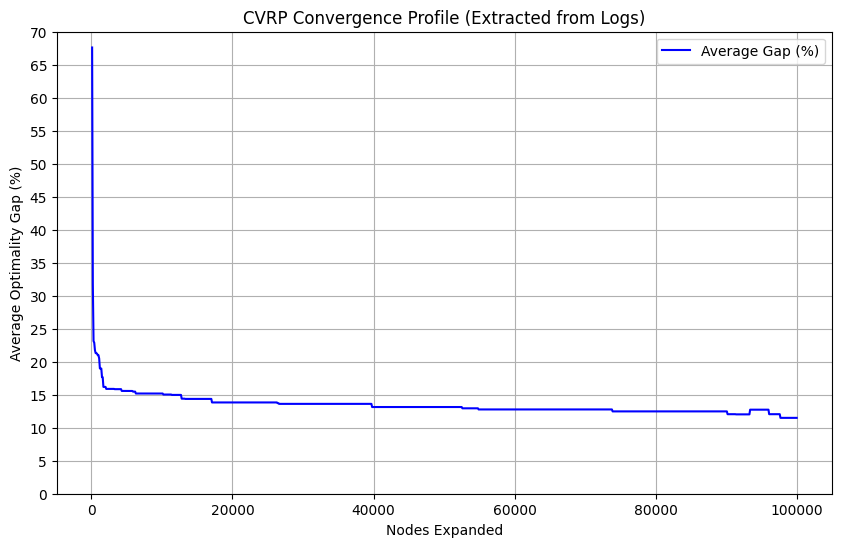

In [1]:
import pandas as pd
import numpy as np
import os
import re
import glob
import math
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ CONFIGURATION
# ==========================================
# Folder containing the 'solver_log_*.txt' files
LOG_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Solve_CVRP_time_limit\v1\v1_CVRP_EA_dual_bound_solver_logs_1800s_lim" 

# File containing Best Known Costs (BKS)
REF_RESULTS_CSV = "CVRP_single_dual_bound_selected_results_10s_lim.csv"

# Output for the processed profiles
OUTPUT_FOLDER = "CVRP_EA_dual_bound_Parsing_Expansion_Limit_Results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

NODE_EXPANSION_LIMIT = 100_000 

# ==========================================
# 🧩 HELPER FUNCTIONS
# ==========================================
def parse_solver_log(file_path):
    """
    Reads log line-by-line. Tracks current best cost.
    Records history points for BOTH 'New primal bound' and 'Searched with beam size'.
    Stops reading immediately when expansion exceeds NODE_EXPANSION_LIMIT.
    """
    history = []
    current_best_cost = float('inf')
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                
                # 1. Check for New Primal Bound (Update State)
                match_primal = re.search(r"New primal bound:\s*([0-9\.\+\-eE]+),\s*expanded:\s*(\d+)", line)
                if match_primal:
                    cost = float(match_primal.group(1))
                    expanded = int(match_primal.group(2))
                    
                    current_best_cost = cost
                    history.append((expanded, cost))
                    
                    if expanded > NODE_EXPANSION_LIMIT:
                        break
                    continue

                # 2. Check for Beam Search Progress (Record State)
                match_beam = re.search(r"Searched with beam size:.*expanded:\s*(\d+)", line)
                if match_beam:
                    expanded = int(match_beam.group(1))
                    history.append((expanded, current_best_cost))
                    
                    if expanded > NODE_EXPANSION_LIMIT:
                        break
                        
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    
    history.sort(key=lambda x: x[0])
    return history

def calculate_dense_gaps(history, optimal_cost, limit):
    sample_rate = 100 
    max_steps = limit // sample_rate
    dense_gaps = np.full(max_steps, np.nan)

    if not history: 
        return dense_gaps, sample_rate 

    current_cost = float('inf')
    hist_idx = 0
    
    # 🟢 NEW: Get the last actual expansion point recorded
    last_real_expansion = history[-1][0]

    for i in range(max_steps):
        current_node_count = (i + 1) * sample_rate
        
        # 🟢 NEW: CUTOFF LOGIC
        # If we are asking for a node count that didn't happen in the log, stop.
        if current_node_count > last_real_expansion:
            break

        # (Original logic continues...)
        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            if history[hist_idx][1] < current_cost:
                current_cost = history[hist_idx][1]
            hist_idx += 1
            
        if current_cost == float('inf'):
            gap = 100.0 
        else:
            denom = optimal_cost if optimal_cost > 0 else 1.0
            gap = (current_cost - optimal_cost) / denom * 100.0
            if gap < 0: gap = 0.0 
            
        dense_gaps[i] = gap
        
    return dense_gaps, sample_rate

# ==========================================
# 🚀 MAIN EXECUTION
# ==========================================
def run_log_parsing():
    print(f"🔹 Starting Log Parsing from: {LOG_DIR}")
    
    # 1. Load BKS Reference
    if not os.path.exists(REF_RESULTS_CSV):
        print(f"❌ Reference CSV missing: {REF_RESULTS_CSV}")
        return
    
    df_ref = pd.read_csv(REF_RESULTS_CSV)
    
    # Determine cost column (CVRP usually uses 'Best Known Cost' or 'Cost')
    if 'Best Known Cost' in df_ref.columns:
        cost_col = 'Best Known Cost'
    elif 'Cost' in df_ref.columns:
        cost_col = 'Cost'
    else:
        print("❌ Could not find 'Cost' or 'Best Known Cost' column in CSV.")
        return

    bks_map = {
        str(row['Instance']).replace(".txt", "").replace(".vrp", "").strip(): float(row[cost_col]) 
        for _, row in df_ref.iterrows()
    }

    # 2. Find Log Files
    log_files = glob.glob(os.path.join(LOG_DIR, "solver_log_*.txt"))
    print(f"   Found {len(log_files)} log files.")
    
    all_dense_gaps = []

    for log_path in log_files:
        filename = os.path.basename(log_path)
        name_clean = filename.replace("solver_log_", "").replace(".txt", "").strip()
        
        if name_clean not in bks_map:
            # Fallback fuzzy match
            found = False
            for k in bks_map.keys():
                if k in name_clean or name_clean in k:
                    name_clean = k
                    found = True
                    break
            if not found:
                continue

        opt_cost = bks_map[name_clean]
        
        # Parse History
        history = parse_solver_log(log_path)
        
        if history:
            dense_gaps, step_size = calculate_dense_gaps(history, opt_cost, NODE_EXPANSION_LIMIT)
            all_dense_gaps.append(dense_gaps)
            
            # Save Individual Profile
            df_hist = pd.DataFrame({
                'Node_Count': np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size),
                'Gap_Percent': dense_gaps
            })
            df_hist.to_csv(os.path.join(OUTPUT_FOLDER, f"gap_profile_{name_clean}.csv"), index=False)

    # 3. Aggregation & Plotting
    if all_dense_gaps:
        print("\n📊 Aggregating Results...")
        gap_matrix = np.vstack(all_dense_gaps)
        
        with np.errstate(invalid='ignore'):
            mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        x_axis = np.arange(100, NODE_EXPANSION_LIMIT + 1, 100)
        
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        
        agg_path = os.path.join(OUTPUT_FOLDER, "CVRP_Average_Gaps_vs_Expansion.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"   ✅ Saved aggregated data to {agg_path}")
        
        # Plot
        plt.figure(figsize=(10, 6))
        plt.plot(x_axis, mean_gaps, label='Average Gap (%)', color='blue')
        
        # 5-Step Y-Axis Logic
        max_y = np.nanmax(mean_gaps) if len(mean_gaps) > 0 else 100
        if pd.isna(max_y): max_y = 100
        upper_limit = math.ceil(max_y / 5) * 5
        
        plt.yticks(np.arange(0, upper_limit + 5, 5))
        plt.ylim(0, upper_limit)

        plt.xlabel('Nodes Expanded')
        plt.ylabel('Average Optimality Gap (%)')
        plt.title('CVRP Convergence Profile (Extracted from Logs)')
        plt.grid(True)
        plt.legend()
        plt.savefig(os.path.join(OUTPUT_FOLDER, "convergence_plot.png"))
        print(f"   ✅ Saved plot to {OUTPUT_FOLDER}")
        plt.show() 
        
    else:
        print("\n⚠️ No valid data extracted.")

if __name__ == "__main__":
    run_log_parsing()

# Backup

🔹 Starting Log Parsing from: C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Solve_CVRP_time_limit\v1\v1_CVRP_EA_dual_bound_solver_logs_1800s_lim
   Found 10 log files.
✅ A-n39-k6 (Opt: 831): Found 8 history points.
✅ A-n48-k7 (Opt: 1073): Found 7 history points.
✅ A-n55-k9 (Opt: 1073): Found 8 history points.
✅ A-n69-k9 (Opt: 1159): Found 8 history points.
✅ A-n80-k10 (Opt: 1763): Found 4 history points.
✅ X-n106-k14 (Opt: 26362): Found 6 history points.
✅ X-n162-k11 (Opt: 14138): Found 3 history points.
✅ X-n181-k23 (Opt: 25569): Found 4 history points.
✅ X-n190-k8 (Opt: 16980): Found 3 history points.
✅ X-n204-k19 (Opt: 19565): Found 4 history points.

📊 Aggregating Results...
   ✅ Saved aggregated data to CVRP_EA_dual_bound_Parsing_Expansion_Limit_Results\CVRP_Average_Gaps_vs_Expansion.csv
   ✅ Saved plot to CVRP_EA_dual_bound_Parsing_Expansion_Limit_Results


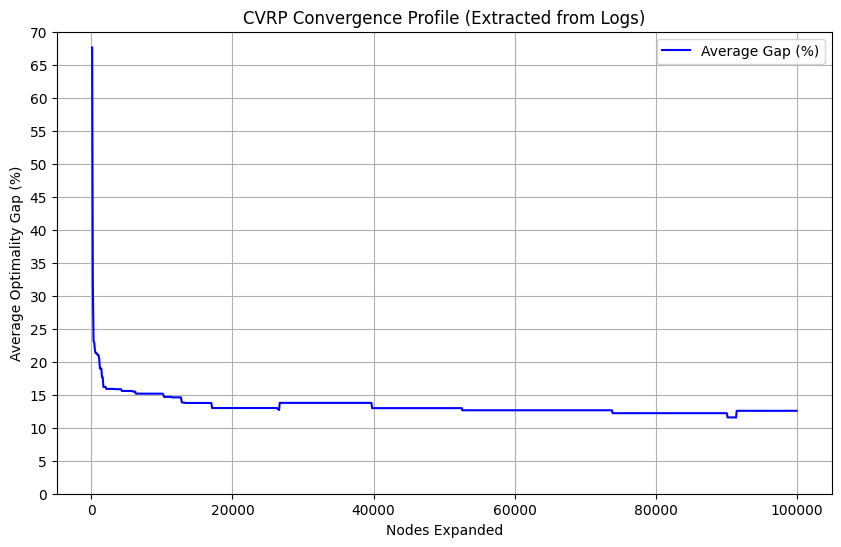

In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import glob
import math  # <--- ADDED for rounding up the axis

# ==========================================
# CONFIGURATION
# ==========================================
# Folder containing the 'solver_log_*.txt' files
LOG_DIR = r"C:\Users\ACER\Desktop\Code\0_Thesis_implementation\2_DIDP_custom_search_guidance_local\Thesis_modified_DIDP\3_CVRP_dual_bounds_and_models\Solve_CVRP_time_limit\v1\v1_CVRP_EA_dual_bound_solver_logs_1800s_lim" 

# File containing Best Known Costs (BKS)
REF_RESULTS_CSV = "CVRP_single_dual_bound_selected_results_10s_lim.csv"

# Output for the processed profiles
OUTPUT_FOLDER = "CVRP_EA_dual_bound_Parsing_Expansion_Limit_Results"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

NODE_EXPANSION_LIMIT = 100_000 

# ==========================================
# HELPER: PARSE LOG FILE
# ==========================================
def parse_solver_log(file_path):
    """
    Reads a solver log and extracts (expanded, cost) tuples 
    from 'New primal bound' lines.
    """
    history = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # Look for: "New primal bound: 27704.77, expanded: 181, ..."
            match = re.search(r"New primal bound:\s*([\d\.]+),\s*expanded:\s*(\d+)", line)
            if match:
                cost = float(match.group(1))
                expanded = int(match.group(2))
                history.append((expanded, cost))
    
    # Sort by expansion count
    history.sort(key=lambda x: x[0])
    return history

# ==========================================
# HELPER: DENSE GAP CALCULATION
# ==========================================
def calculate_dense_gaps(history, optimal_cost, limit):
    sample_rate = 100 
    max_steps = limit // sample_rate
    dense_gaps = np.full(max_steps, np.nan)

    if not history: 
        return dense_gaps, sample_rate 

    current_cost = float('inf')
    hist_idx = 0
    
    for i in range(max_steps):
        current_node_count = (i + 1) * sample_rate
        
        # Stop assuming if we passed the actual history (No Flatline)
        if hist_idx >= len(history) and history[-1][0] < current_node_count:
             break

        while hist_idx < len(history) and history[hist_idx][0] <= current_node_count:
            if history[hist_idx][1] < current_cost:
                current_cost = history[hist_idx][1]
            hist_idx += 1
            
        if current_cost == float('inf'):
            gap = 100.0 
        else:
            denom = optimal_cost if optimal_cost > 0 else 1.0
            gap = (current_cost - optimal_cost) / denom * 100.0
            if gap < 0: gap = 0.0 
            
        dense_gaps[i] = gap
        
    return dense_gaps, sample_rate

# ==========================================
# MAIN EXECUTION
# ==========================================
def run_log_parsing():
    print(f"🔹 Starting Log Parsing from: {LOG_DIR}")
    
    # 1. Load BKS Reference
    if not os.path.exists(REF_RESULTS_CSV):
        print(f"❌ Reference CSV missing: {REF_RESULTS_CSV}")
        return
    
    df_ref = pd.read_csv(REF_RESULTS_CSV)
    bks_map = {}
    for _, row in df_ref.iterrows():
        clean_name = row['Instance'].replace(".vrp", "").strip()
        bks_map[clean_name] = row['Best Known Cost']

    # 2. Find Log Files
    log_pattern = os.path.join(LOG_DIR, "solver_log_*.txt")
    log_files = glob.glob(log_pattern)
    
    if not log_files:
        print(f"❌ No log files found matching: {log_pattern}")
        return

    all_dense_gaps = []
    
    print(f"   Found {len(log_files)} log files.")

    for log_file in log_files:
        filename = os.path.basename(log_file)
        instance_name = filename.replace("solver_log_", "").replace(".txt", "").strip()
        
        if instance_name not in bks_map:
            print(f"⚠️  Skipping {instance_name}: No BKS found in reference CSV.")
            continue
            
        optimal_cost = bks_map[instance_name]
        
        # Parse History directly from log
        history = parse_solver_log(log_file)
        
        if not history:
            print(f"⚠️  {instance_name}: No 'New primal bound' lines found in log.")
            continue
            
        print(f"✅ {instance_name} (Opt: {optimal_cost}): Found {len(history)} history points.")
        
        # Calculate Profile
        dense_gaps, step_size = calculate_dense_gaps(history, optimal_cost, NODE_EXPANSION_LIMIT)
        all_dense_gaps.append(dense_gaps)
        
        # Save Individual Profile
        df_hist = pd.DataFrame({
            'Node_Count': np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size),
            'Gap_Percent': dense_gaps
        })
        output_csv = os.path.join(OUTPUT_FOLDER, f"gap_profile_{instance_name}.csv")
        df_hist.to_csv(output_csv, index=False)

    # 3. Aggregation & Plotting
    if all_dense_gaps:
        print("\n📊 Aggregating Results...")
        gap_matrix = np.vstack(all_dense_gaps)
        
        # Calculate Mean (ignoring NaNs)
        with np.errstate(invalid='ignore'):
            mean_gaps = np.nanmean(gap_matrix, axis=0)
        
        step_size = 100
        x_axis = np.arange(step_size, NODE_EXPANSION_LIMIT + 1, step_size)
        
        df_agg = pd.DataFrame({
            'Node_Count': x_axis,
            'Average_Gap_Percent': mean_gaps
        })
        
        agg_path = os.path.join(OUTPUT_FOLDER, "CVRP_Average_Gaps_vs_Expansion.csv")
        df_agg.to_csv(agg_path, index=False)
        print(f"   ✅ Saved aggregated data to {agg_path}")
        
        # Plot
        plt.figure(figsize=(10, 6))
        plt.plot(x_axis, mean_gaps, label='Average Gap (%)', color='blue')
        
        # --- MODIFIED Y-AXIS LOGIC ---
        # 1. Find the maximum gap value to determine the graph height
        max_y_val = np.nanmax(mean_gaps)
        
        # 2. Round up to the nearest multiple of 5 (e.g., 13 -> 15, 21 -> 25)
        upper_limit = math.ceil(max_y_val / 5) * 5
        
        # 3. Create ticks: 0, 5, 10, ... up to upper_limit
        # np.arange(start, stop, step) - stop is exclusive, so we add 5
        plt.yticks(np.arange(0, upper_limit + 5, 5))
        
        # 4. Enforce the limit starting at 0
        plt.ylim(0, upper_limit)
        # -----------------------------

        plt.xlabel('Nodes Expanded')
        plt.ylabel('Average Optimality Gap (%)')
        plt.title('CVRP Convergence Profile (Extracted from Logs)')
        plt.grid(True)
        plt.legend()
        plt.savefig(os.path.join(OUTPUT_FOLDER, "convergence_plot.png"))
        print(f"   ✅ Saved plot to {OUTPUT_FOLDER}")
        plt.show() # Display plot if using Notebook
        
    else:
        print("\n⚠️ No valid data extracted.")

if __name__ == "__main__":
    run_log_parsing()